In [5]:
import os
if not os.getcwd().endswith("Simglucose_suite"):
    os.chdir("..")

from baseline_controllers.BBControllerWrapper import BBPolicy
from baseline_controllers.PIDControllerWrapper import PIDPolicy
from evaluate2 import evaluate_insulin_policy
from envs.env_open import make_simglucose_spid_env
from train import TrainConfig

import json
from pathlib import Path


In [6]:

folder_path = Path("./models/open_optuna_optimal/clarke_risk/adult-001")
config_path = folder_path / "train_config.json"

with open(config_path, "r", encoding="utf-8") as f:
    config_dict = json.load(f)

config = TrainConfig(**config_dict)

env = make_simglucose_spid_env(
    patient_name="adult#001", #config.patient,
    meal_schedule=config.meals,
    env_id="simglucose-spid-eval-v0",
    max_episode_steps=config.max_episode_steps*3,
    normalize=False,
    scenario_mode="semi_random_hb", #config.scenario_mode,
    seed=None,
    warning_window_min=1,
    insulin_tau_min=config.insulin_tau_min,
    sample_time_min=config.sample_time_min,
    time_std_multiplier=2.5, # config.time_std_multiplier,
    include_snacks=config.include_snacks,
    amount_noise_std_fraction=0.4, #config.amount_noise_std_fraction,
    actual_time_noise_std_min= 10, #config.actual_time_noise_std_min,
    actual_time_noise_clip_min= 30, #config.actual_time_noise_clip_min,
    reward_type=config.reward_type,
    max_insulin_action=10, #config.max_insulin_action,
    shield_bg_threshold=config.shield_bg_threshold,
    use_bb_warmup=config.use_bb_warmup,
)

policy = PIDPolicy(env=env, target_BG=140, max_insulin_action=10)

In [7]:
policy.patient_name

'adult#001'

/home/ashc/miniforge3/envs/thesis-rl/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.env_method to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.env_method` for environment variables or `env.get_wrapper_attr('env_method')` that will search the reminding wrappers.
  logger.warn(


HISTORY CLEARED
Evaluating insulin policy...


/home/ashc/miniforge3/envs/thesis-rl/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_attr to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_attr` for environment variables or `env.get_wrapper_attr('get_attr')` that will search the reminding wrappers.
  logger.warn(


Generating simglucose report...


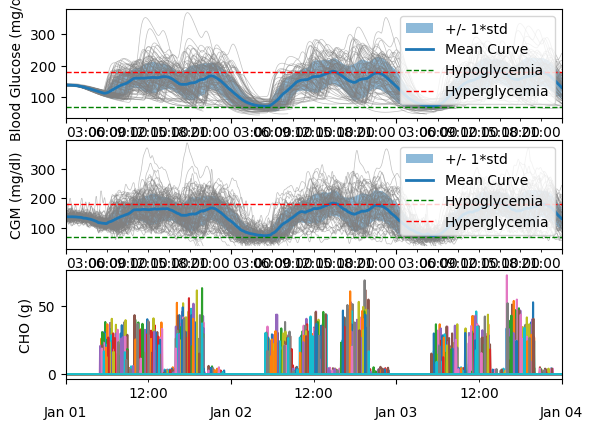

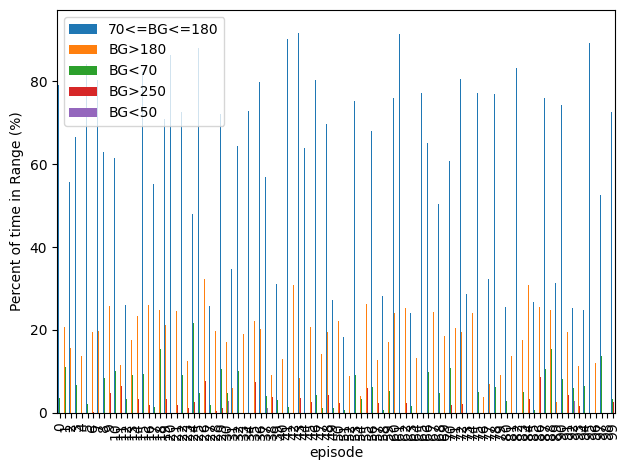

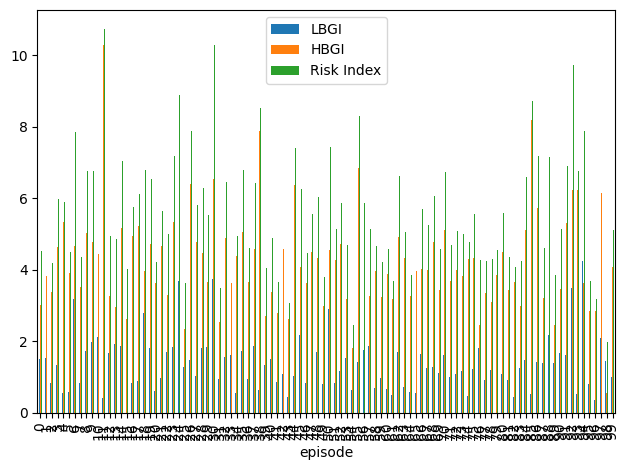

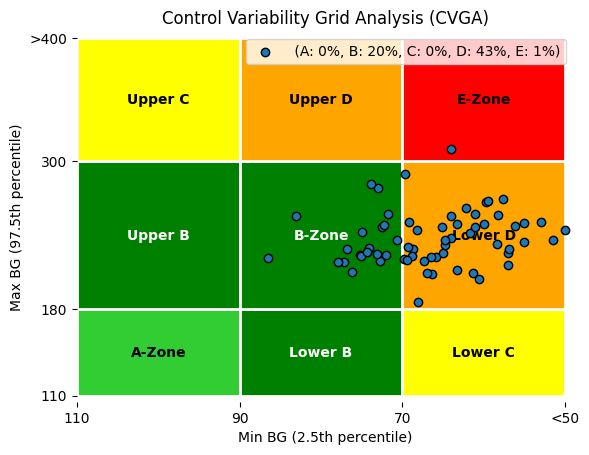

HISTORY CLEARED


/home/ashc/miniforge3/envs/thesis-rl/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.env_method to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.env_method` for environment variables or `env.get_wrapper_attr('env_method')` that will search the reminding wrappers.
  logger.warn(


{'metrics': {'eval_index': 0,
  'TBR_II': 0.4684793903706269,
  'TBR_I': 6.0417388292345,
  'TIR': 72.85157603048147,
  'TAR_I': 21.106685140284032,
  'TAR_II': 1.9050917907862834,
  'total_daily_insulin': 0.0,
  'average_insulin': nan,
  'TBR_II_episode_mean': 0.6138117092206629,
  'TBR_II_episode_std': 2.050074253824098,
  'TBR_II_ti90_95_lower': 0.0,
  'TBR_II_ti90_95_upper': 9.042553191489363,
  'TBR_I_episode_mean': 6.097879964767403,
  'TBR_I_episode_std': 4.972857251425375,
  'TBR_I_ti90_95_lower': 0.0,
  'TBR_I_ti90_95_upper': 18.857142857142858,
  'TIR_episode_mean': 72.30769995320999,
  'TIR_episode_std': 9.945746430163819,
  'TIR_ti90_95_lower': 47.883414295628036,
  'TIR_ti90_95_upper': 91.53365718251214,
  'TAR_I_episode_mean': 21.594420082022598,
  'TAR_I_episode_std': 7.6890804874943806,
  'TAR_I_ti90_95_lower': 7.0784177654406655,
  'TAR_I_ti90_95_upper': 37.00934579439252,
  'TAR_II_episode_mean': 2.0998665929527167,
  'TAR_II_episode_std': 3.427274431779803,
  'TAR_II

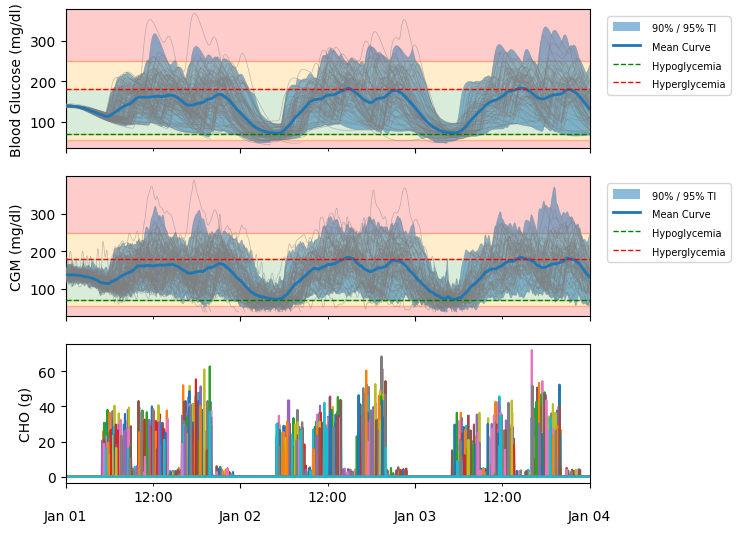

In [10]:
%matplotlib inline
evaluate_insulin_policy(policy, env, n_eval_episodes=100, save_path="./3-day-test/adult-001/PID/")